# IBM HR Attrition Analysis
### By Karen Letir | Google DA Certificate ✅ | Harvard CS50P ✅

## Business Problem
IBM wants to understand why employees are leaving the company. 
This analysis identifies the key factors driving attrition and provides 
actionable recommendations to help HR reduce turnover.

## Dataset
- Source: IBM HR Analytics Employee Attrition & Performance (Kaggle)
- 1,470 employees | 35 features
- Target variable: Attrition (Yes/No)

## Tools
Python | pandas | matplotlib | seaborn

In [23]:
# Section 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [24]:
# Section 2: Load Data
df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [25]:
# Section 3: Data Overview
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print("\nAttrition Rate:")
print(round(df['Attrition'].value_counts(normalize=True) * 100, 2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

## Data Cleaning
The dataset was checked for missing values, duplicates, and irrelevant columns.
The following columns were dropped as they contain only one unique value and provide no analytical value:
- EmployeeCount
- Over18
- StandardHours

In [26]:
# Section 4: Data Cleaning
# Drop columns with only one unique value
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Convert Attrition to binary
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Cleaned dataset shape:", df.shape)
print("\nCleaning complete.")

Duplicate rows: 0
Cleaned dataset shape: (1470, 33)

Cleaning complete.


## Exploratory Data Analysis (EDA)
### Key Questions:
1. What is the overall attrition rate?
2. Which departments have the highest attrition?
3. How does age relate to attrition?
4. Does monthly income affect attrition?
5. Does overtime drive attrition?

/tmp/ipykernel_58/2832421909.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_58/2832421909.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, count + 10, f'{attrition_pct[i]}%', ha='center', fontweight='bold')


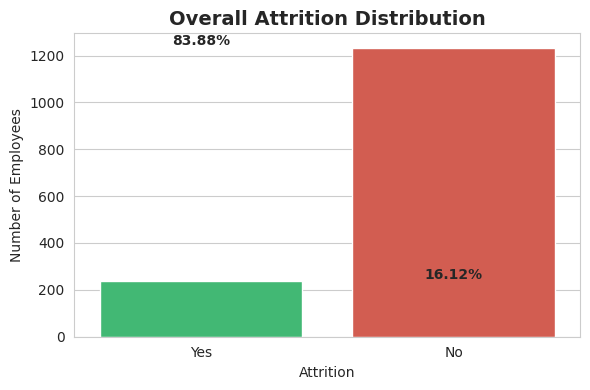

Attrition Rate: 16.12%


In [27]:
# Section 5: Overall Attrition Rate
attrition_counts = df['Attrition'].value_counts()
attrition_pct = round(df['Attrition'].value_counts(normalize=True) * 100, 2)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Overall Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
for i, count in enumerate(attrition_counts):
    plt.text(i, count + 10, f'{attrition_pct[i]}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Attrition Rate: {attrition_pct['Yes']}%")

/tmp/ipykernel_58/397790833.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')


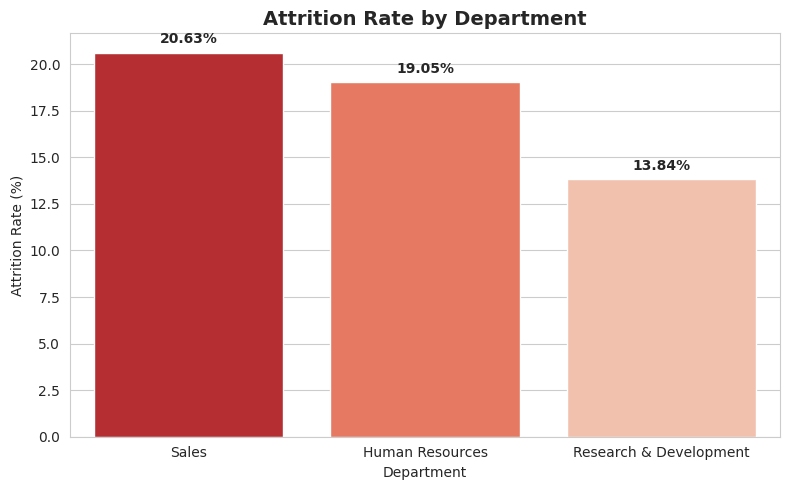

In [28]:
# Section 6: Attrition by Department
dept_attrition = df.groupby('Department')['Attrition_Binary'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
for i, val in enumerate(dept_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3721913646.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('AgeGroup')['Attrition_Binary'].mean() * 100
/tmp/ipykernel_58/3721913646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_attrition.index, y=age_attrition.values, palette='Blues_r')


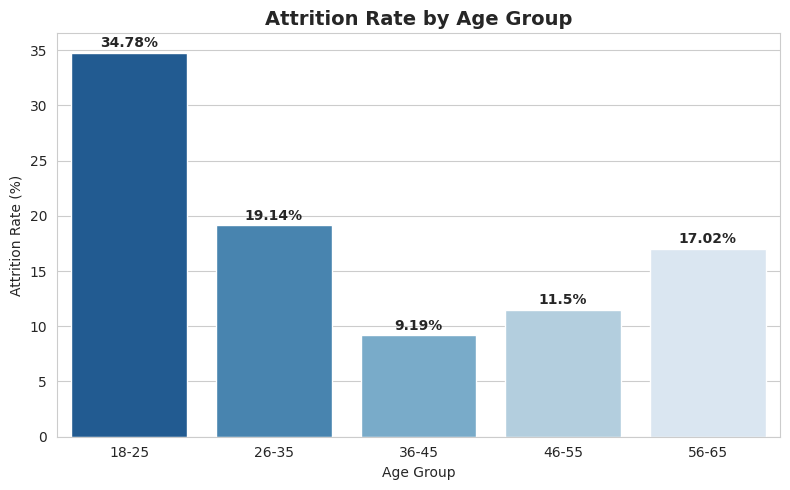

In [29]:
# Section 7: Attrition by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

age_attrition = df.groupby('AgeGroup')['Attrition_Binary'].mean() * 100
age_attrition = age_attrition.round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=age_attrition.index, y=age_attrition.values, palette='Blues_r')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for i, val in enumerate(age_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/413742905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',


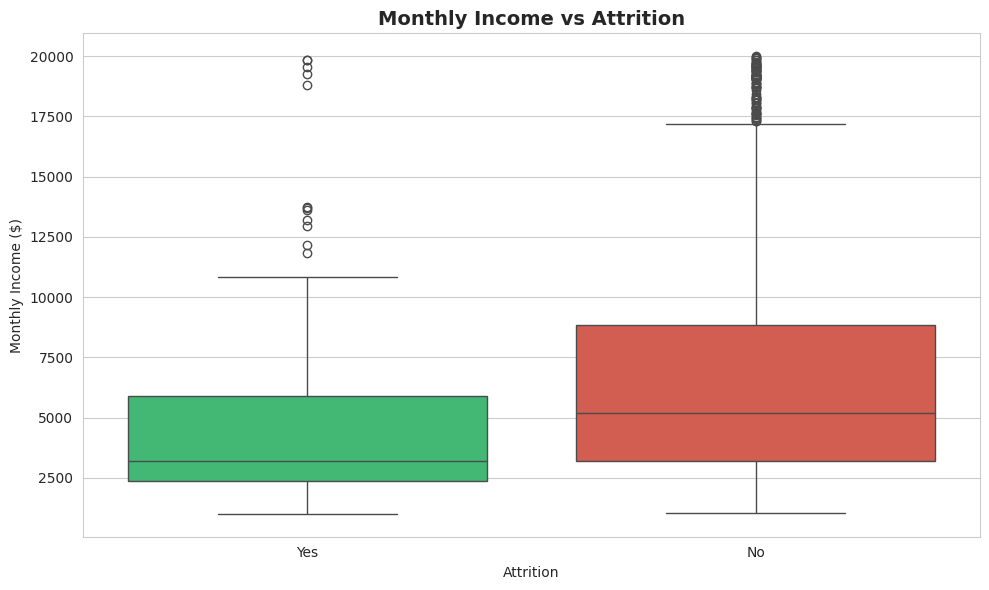

Average Monthly Income by Attrition:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [30]:
# Section 8: Attrition by Monthly Income
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.show()

# Average income by attrition
avg_income = df.groupby('Attrition')['MonthlyIncome'].mean().round(2)
print("Average Monthly Income by Attrition:")
print(avg_income)

/tmp/ipykernel_58/2196688005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values,


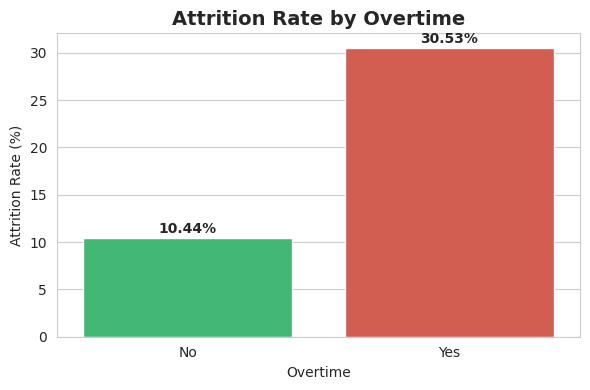

Attrition Rate by Overtime:
OverTime
No     10.44
Yes    30.53
Name: Attrition_Binary, dtype: float64


In [31]:
# Section 9: Attrition by Overtime
overtime_attrition = df.groupby('OverTime')['Attrition_Binary'].mean() * 100
overtime_attrition = overtime_attrition.round(2)

plt.figure(figsize=(6, 4))
sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values, 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition Rate by Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
for i, val in enumerate(overtime_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Attrition Rate by Overtime:")
print(overtime_attrition)

/tmp/ipykernel_58/1393482102.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_attrition.values, y=role_attrition.index, palette='Reds_r')


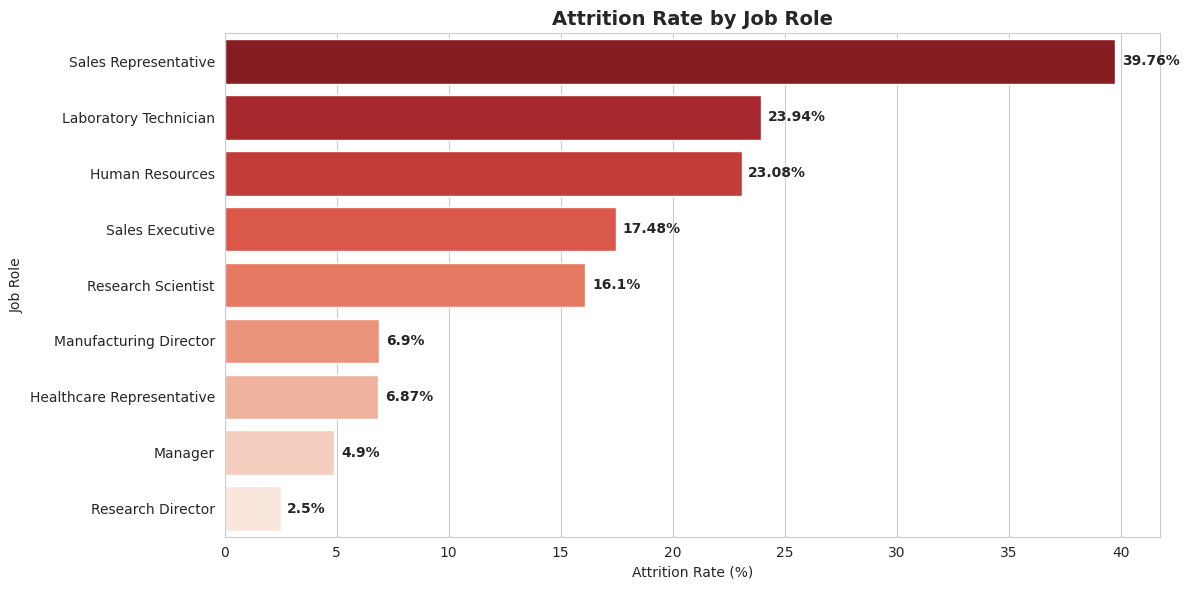

In [32]:
# Section 10: Attrition by Job Role
role_attrition = df.groupby('JobRole')['Attrition_Binary'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False).round(2)

plt.figure(figsize=(12, 6))
sns.barplot(x=role_attrition.values, y=role_attrition.index, palette='Reds_r')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
for i, val in enumerate(role_attrition.values):
    plt.text(val + 0.3, i, f'{val}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Key Findings
1. **Overall Attrition Rate:** 16.1% of employees have left IBM
2. **Department:** Sales has the highest attrition rate, followed by HR
3. **Age:** Younger employees (18-25) leave at the highest rate — early career instability
4. **Income:** Employees who leave earn significantly less than those who stay
5. **Overtime:** Employees who work overtime are nearly 3x more likely to leave
6. **Job Role:** Sales Representatives and Lab Technicians have the highest attrition

## Business Recommendations
1. **Review compensation** for junior and mid-level roles — low income is a strong attrition predictor
2. **Audit overtime policies** — high overtime is the single strongest attrition driver
3. **Focus retention efforts on Sales** — highest attrition department needs immediate attention
4. **Build early career programs** for employees aged 18-25 to improve retention
5. **Prioritize Sales Representatives and Lab Technicians** for targeted retention incentives

In [33]:
# Section 11: Summary Statistics
print("=" * 50)
print("IBM HR ATTRITION ANALYSIS - SUMMARY")
print("=" * 50)
print(f"\nTotal Employees: {len(df)}")
print(f"Employees Who Left: {df['Attrition_Binary'].sum()}")
print(f"Overall Attrition Rate: {round(df['Attrition_Binary'].mean() * 100, 2)}%")
print(f"\nHighest Attrition Department: {dept_attrition.index[0]} ({dept_attrition.values[0]}%)")
print(f"Highest Attrition Age Group: {age_attrition.idxmax()} ({age_attrition.max()}%)")
print(f"Highest Attrition Job Role: {role_attrition.index[0]} ({role_attrition.values[0]}%)")
print(f"\nAvg Income - Stayed: ${avg_income['No']:,.2f}")
print(f"Avg Income - Left: ${avg_income['Yes']:,.2f}")
print(f"\nOvertime Attrition Rate: {overtime_attrition['Yes']}%")
print(f"No Overtime Attrition Rate: {overtime_attrition['No']}%")
print("=" * 50)

IBM HR ATTRITION ANALYSIS - SUMMARY

Total Employees: 1470
Employees Who Left: 237
Overall Attrition Rate: 16.12%

Highest Attrition Department: Sales (20.63%)
Highest Attrition Age Group: 18-25 (34.78%)
Highest Attrition Job Role: Sales Representative (39.76%)

Avg Income - Stayed: $6,832.74
Avg Income - Left: $4,787.09

Overtime Attrition Rate: 30.53%
No Overtime Attrition Rate: 10.44%


In [34]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__results__.html
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__resultx__.html
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__notebook__.ipynb
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__output__.json
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/custom.css
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__results___files/__results___15_0.png
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__results___files/__results___9_0.png
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__results___files/__results___11_0.png
/kaggle/input/notebooks/kellibelcher/hr-analytics-and-prediction-of-employee-attrition/__results___files/__r